In [2]:
import requests
import os
from dotenv import load_dotenv
from itertools import combinations
from collections import Counter
import networkx as nx
import json
from networkx.readwrite import json_graph
import netwulf as nw
import matplotlib.pyplot as plt
from datetime import datetime

# Get cinema‑released movies from TMDb

In [ ]:
load_dotenv()
API_KEY = os.getenv("TMDB_API_KEY")

BASE = "https://api.themoviedb.org/3/discover/movie"

params = {
    "api_key": API_KEY,
    "with_release_type": 3,
    "sort_by": "popularity.desc",
    "primary_release_date.gte": "2000-01-01",
}

# -- Pagination --
all_movies = []

for page in range(1, 6):  # first 5 pages = 100 movies
    params["page"] = page
    r_movies = requests.get(BASE, params=params).json()
    all_movies.extend(r_movies["results"])

In [63]:
# Extract movie IDs and Titles as tuples of (ID, Title)
titles = [(m.get("id"), m.get("title"), m.get("popularity"), m.get("vote_average"), m.get("vote_count"), m.get("release_date"), m.get("original_language")) for m in all_movies]
titles[0:5]

[(1226863,
  'The Super Mario Galaxy Movie',
  718.7308,
  6.817,
  483,
  '2026-04-01',
  'en'),
 (1523145,
  'Your Heart Will Be Broken',
  377.5413,
  7.213,
  61,
  '2026-03-26',
  'ru'),
 (83533, 'Avatar: Fire and Ash', 306.1776, 7.4, 2617, '2025-12-17', 'en'),
 (687163, 'Project Hail Mary', 263.6881, 8.213, 1488, '2026-03-15', 'en'),
 (1290417, 'Thrash', 222.0529, 5.967, 302, '2026-04-10', 'en')]

In [103]:
len(titles)

100

# Get actors for each movie

In [64]:
credits_by_movie = {}

for movie_id, movie_title, _, _, _, _, _ in titles:
    url = f"https://api.themoviedb.org/3/movie/{movie_id}/credits"
    params = {"api_key": API_KEY}

    r_cast = requests.get(url, params=params).json()

    # Take top 10 billed actors
    top_cast = sorted(r_cast.get("cast", []), key=lambda x: x["order"])[:10]

    credits_by_movie[movie_id] = {
        "id": movie_id,
        "cast": [
            {
                "actor_id": a["id"],
                "name": a["name"],
                "order": a["order"]
            }
            for a in top_cast
        ]
    }

In [65]:
credits_by_movie[350]

{'id': 350,
 'cast': [{'actor_id': 5064, 'name': 'Meryl Streep', 'order': 0},
  {'actor_id': 1813, 'name': 'Anne Hathaway', 'order': 1},
  {'actor_id': 5081, 'name': 'Emily Blunt', 'order': 2},
  {'actor_id': 2283, 'name': 'Stanley Tucci', 'order': 3},
  {'actor_id': 1284159, 'name': 'Simon Baker', 'order': 4},
  {'actor_id': 5090, 'name': 'Adrian Grenier', 'order': 5},
  {'actor_id': 10580, 'name': 'Tracie Thoms', 'order': 6},
  {'actor_id': 10581, 'name': 'Rich Sommer', 'order': 7},
  {'actor_id': 10582, 'name': 'Daniel Sunjata', 'order': 8},
  {'actor_id': 24535, 'name': 'David Marshall Grant', 'order': 9}]}

# Build the actor co‑starring network

In [ ]:
# Build graph containing actors ID as nodes and their names as an attribute.
G = nx.Graph()
pair_counts = Counter()

for movie in credits_by_movie.values():
    cast = movie["cast"]
    actor_ids = []

    for a in cast:
        actor_id = a["actor_id"]

        actor_attrs = {
            "display_name": a["name"]
        }

        # Add node with attributes
        G.add_node(actor_id, **actor_attrs)

        actor_ids.append(actor_id)

    # Build co-starring edges
    for a, b in combinations(sorted(actor_ids), 2):
        pair_counts[(a, b)] += 1

In [ ]:
# Weigh edges between actors by number of co-starring movies
Wedgelist = [(a, b, w) for (a, b), w in pair_counts.items()]
G.add_weighted_edges_from(Wedgelist)
Wedgelist[:5]


# Save JSON
data = json_graph.node_link_data(G)
with open(f"ActorGraph.json", "w") as f:
    json.dump(data, f, indent=2, default=int)

In [ ]:
# Read graph from .json file
with open("ActorGraph.json") as f:
    data = json.load(f)

data["links"] = data.pop("edges")

# G = json_graph.node_link_graph(data, edges='edges')


# ----- COLOR NODES BASED ON AN ATTRIBUTE -----
# just map groups to colors
# color_map = {
#     "US": "#fffc47",
#     "CN": "#008006",
#     "DE": "#00ff00",
#     "GB": "#ffc814",
#     "IT": "#77c6ff",
#     "NL": "#ff0ef3"
# }

# for node in data["nodes"]:
#     group_value = node.get("country_code", 0)   # default if missing
#     node["color"] = color_map.get(group_value, "#7f7f7f")  # fallback grey



# ---- AUTO‑COLOR ALL country_code VALUES ----
# codes = [n.get("country_code", "NA") for n in data["nodes"]]
# unique_codes = sorted(set(codes))
# num_codes = len(unique_codes)

# # choose a categorical colormap
# cmap = mpl.colormaps["tab20"]

# # sample N distinct colors from the colormap
# color_list = [mpl_colors.to_hex(cmap(i / num_codes)) for i in range(num_codes)]

# # build code → color mapping
# code_to_color = dict(zip(unique_codes, color_list))

# # assign colors to nodes
# for node in data["nodes"]:
#     node["color"] = code_to_color[node.get("country_code", "NA")]
# ------------------------------------------


network, config = nw.visualize(data, plot_in_cell_below=False)

# -- Save network and config to avoid LONG render times in the browser
with open(f"ActorNetwork.json", "w") as nfile:
    json.dump(network, nfile)

with open(f"ActorConfig.json", "w") as cfile:
    json.dump(config, cfile)

2026-04-18_13-13-02


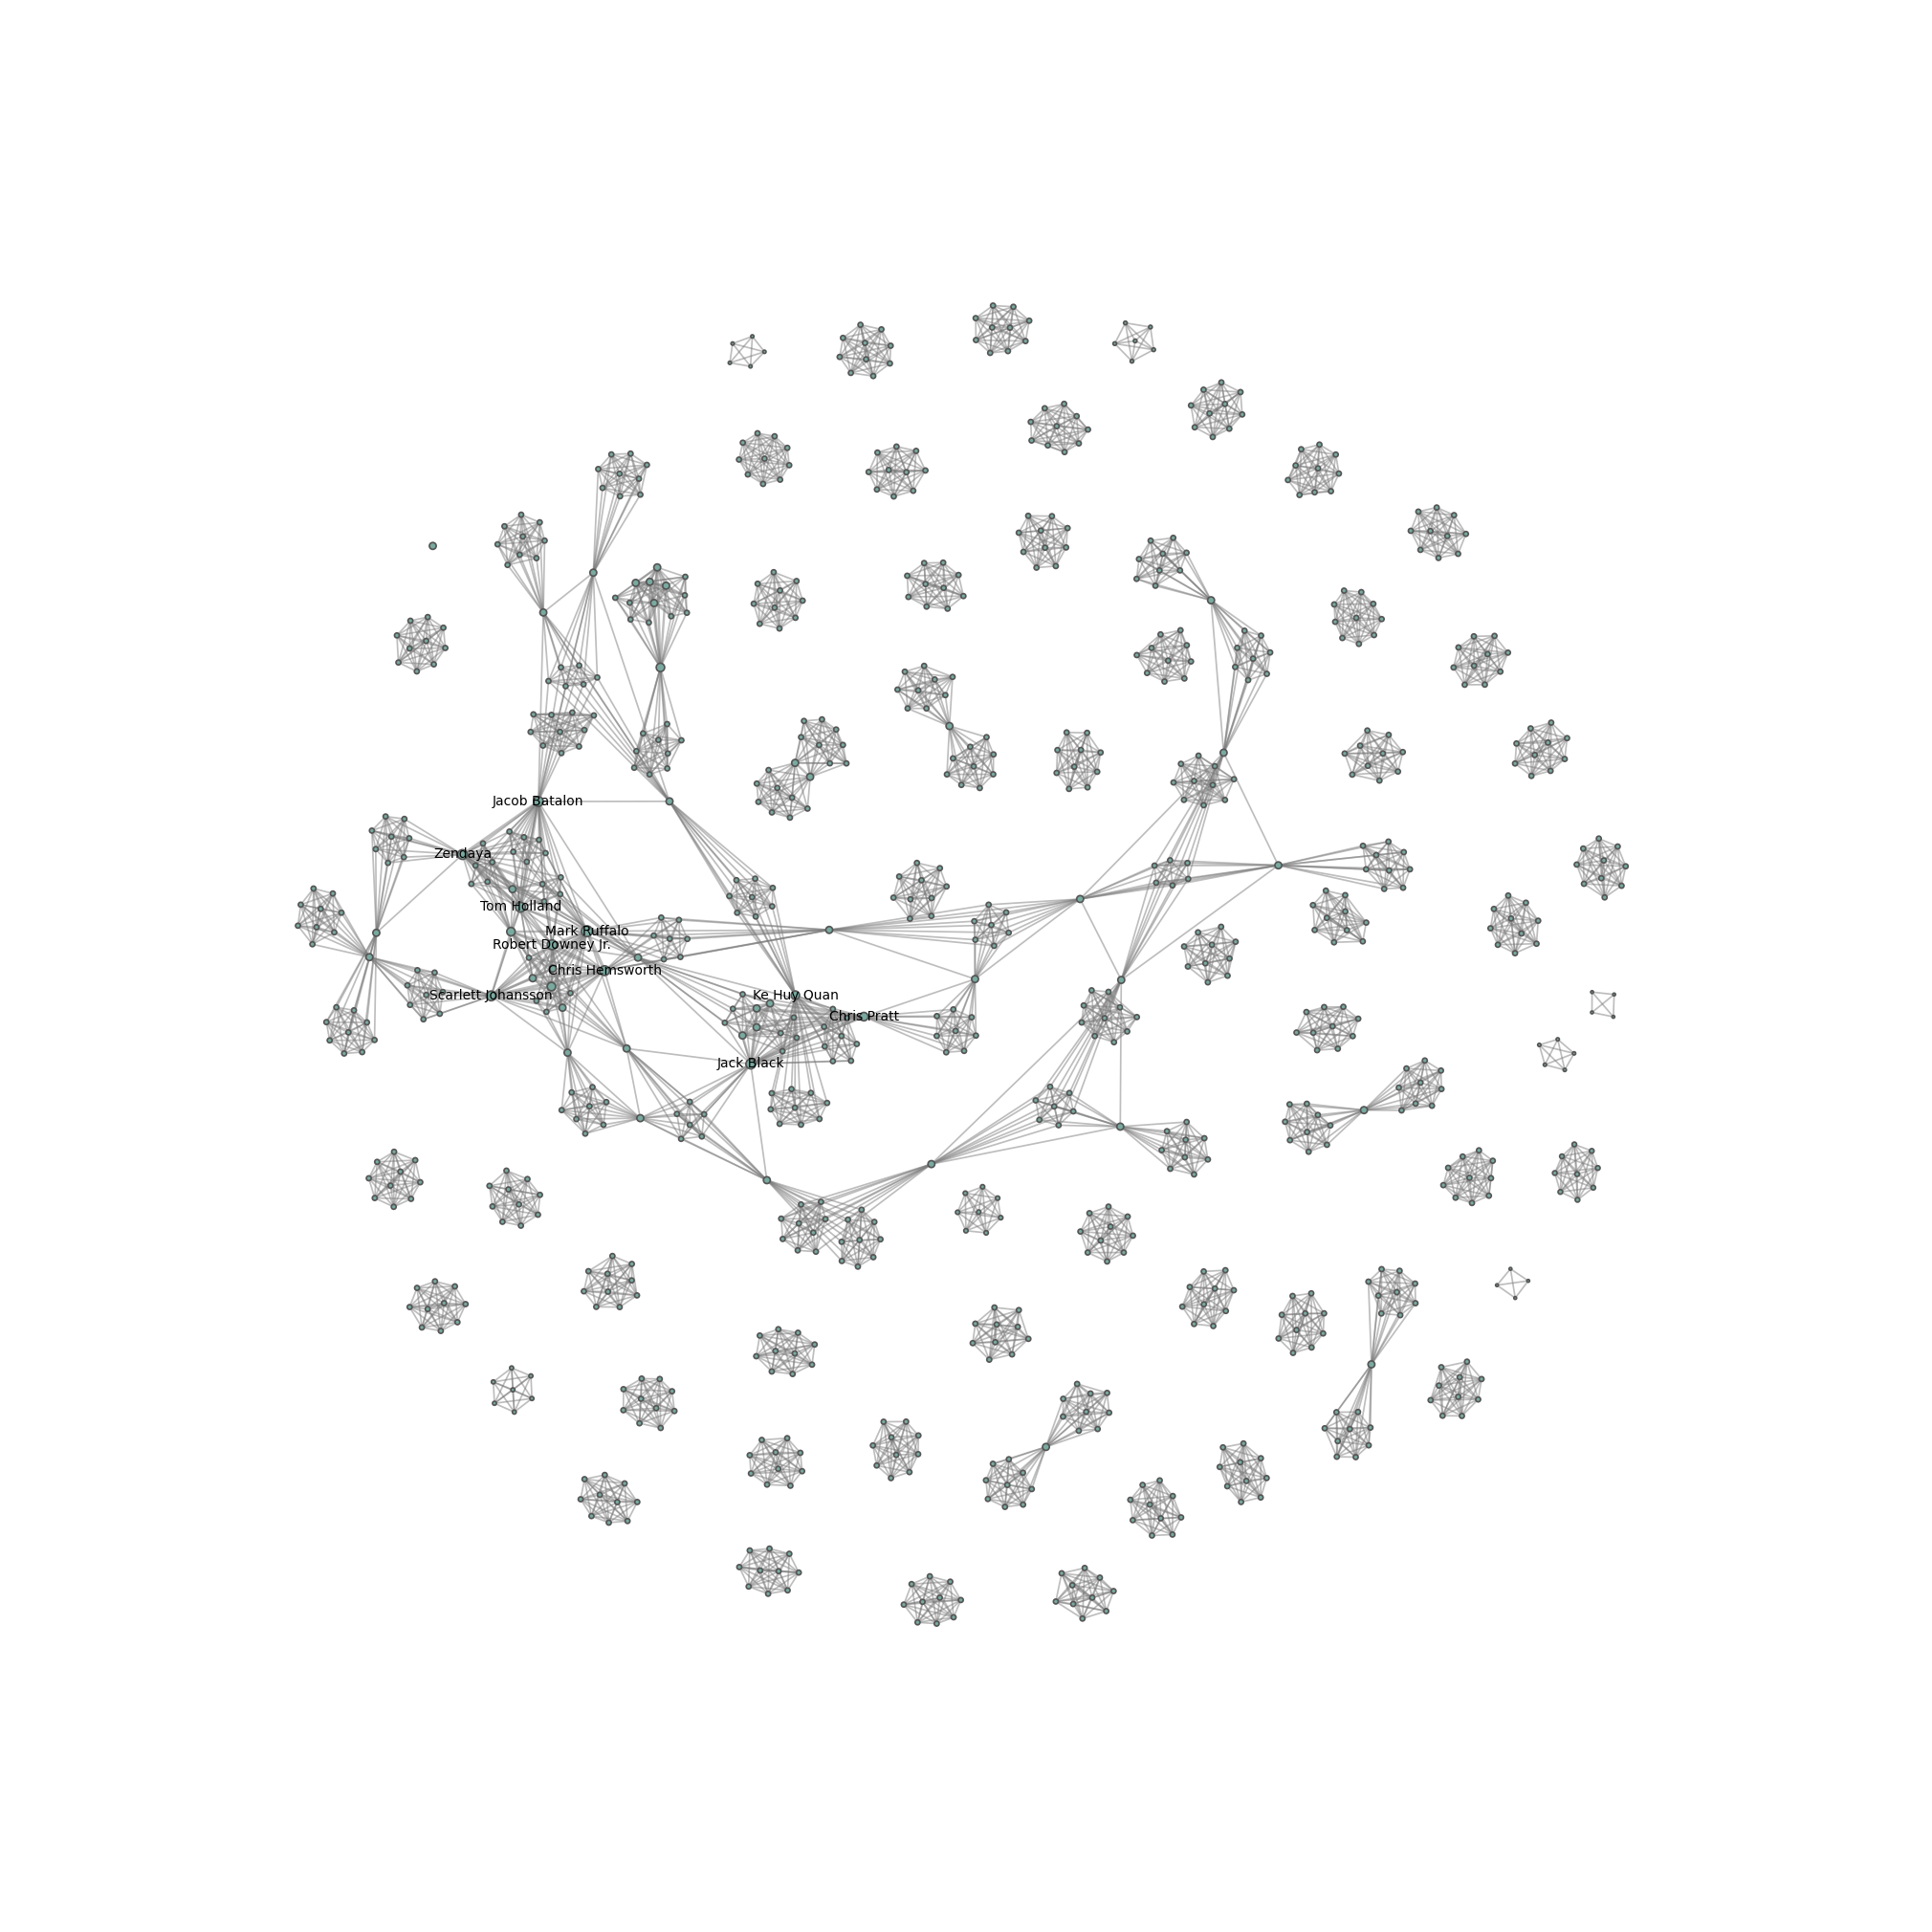

In [ ]:
# draw links first
fig, ax = nw.draw_netwulf(network, figsize=20, draw_nodes=True)

top10 = sorted(G.degree(), key=lambda x: x[1], reverse=True)[0:10]
top10ids = [id for id, _ in top10]

for node in data["nodes"]:
    if node["id"] in top10ids: # Add names of top 5 authors by degree
        nw.add_node_label(ax, network, node["id"], node["display_name"])

# Save the assortativity values
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
print(timestamp)
plt.savefig(f"images/ActorNetworkGraph_{timestamp}.pdf")